# Predict in-season FPL performance based on lagged player performance data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from training.load_training_data import (
    load_historic_player_fixture_data,
)
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from prediction.artifacts.io import save_trained_catboost_model
from prediction.artifacts.path_registry import IN_SEASON_ARTIFACT_PATH



RANDOM_STATE = 12
MAX_HORIZON = 12
ROLLING_WINDOWS = [1, 3, 6, 9, 12]

# Train and evaluate on 2022/23 and 2023/24 seasons

In [2]:
TRAINING_SEASONS = ["2022-23", "2023-24"]

fixture_history_df = pd.concat(
    [
        load_historic_player_fixture_data(season)
        .rename(columns={"GW": "target_gw"})
        .assign(season=season)
        for season in TRAINING_SEASONS
    ],
    ignore_index=True,
    sort=False,
)

fixture_history_df = fixture_history_df.sort_values(
    ["player_id", "season", "target_gw", "fixture_id"]
).reset_index(drop=True)

print(fixture_history_df.groupby("season").size())
fixture_history_df.head()

season
2022-23    26505
2023-24    29725
dtype: int64


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,player_id,...,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,target_gw,season
0,Cédric Alves Soares,DEF,Arsenal,2.4,0,0,0,0,0.0,1,...,0.0,0,0,0,0,45,False,0,1,2022-23
1,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0,-5169,1361,6530,44,True,0,2,2022-23
2,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0,-4337,879,5216,44,False,0,3,2022-23
3,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0,-2988,577,3565,43,True,0,4,2022-23
4,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0,-1611,405,2016,43,True,0,5,2022-23


# Feature engineering

In [3]:
CATEGORICAL_COLUMNS = ["position",
                       "target_gw",
                       "current_gw",
                       "horizon",
    ]

NUMERIC_FEATURES = [
    "total_points",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "goals_conceded",
    "own_goals",
    "penalties_saved",
    "penalties_missed",
    "yellow_cards",
    "red_cards",
    "saves",
    "bonus",
    "bps",
    "influence",
    "creativity",
    "threat",
    "ict_index",
    "starts",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "expected_goals_conceded",
]

TARGET_COLUMN = "total_points"

In [4]:
calculated_feature_dfs = []

for window in ROLLING_WINDOWS:
    rolling_mean_df = (
        fixture_history_df.groupby(["player_id", "season"], sort=False)[
            NUMERIC_FEATURES
        ]
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=["player_id", "season"], drop=True)
        .sort_index()
    )
    rolling_mean_df.columns = [
        f"calc_{feature}_mean_last_{window}_fixtures"
        for feature in NUMERIC_FEATURES
    ]

    rolling_stdev_df = (
        fixture_history_df.groupby(["player_id", "season"], sort=False)[
            NUMERIC_FEATURES
        ]
        .rolling(window=window, min_periods=1)
        .std(ddof=0)
        .reset_index(level=["player_id", "season"], drop=True)
        .sort_index()
    )
    rolling_stdev_df.columns = [
        f"calc_{feature}_stdev_last_{window}_fixtures"
        for feature in NUMERIC_FEATURES
    ]

    rolling_window_df = pd.concat(
        [rolling_mean_df, rolling_stdev_df],
        axis=1,
    ).astype("float32")
    
    calculated_feature_dfs.append(rolling_window_df)

calculated_features_df = pd.concat(calculated_feature_dfs, axis=1)

fixture_history_df = pd.concat(
    [fixture_history_df, calculated_features_df],
    axis=1,
)

calculated_columns = calculated_features_df.columns.tolist()

In [5]:
fixture_history_df.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,player_id,...,calc_bps_stdev_last_12_fixtures,calc_influence_stdev_last_12_fixtures,calc_creativity_stdev_last_12_fixtures,calc_threat_stdev_last_12_fixtures,calc_ict_index_stdev_last_12_fixtures,calc_starts_stdev_last_12_fixtures,calc_expected_goals_stdev_last_12_fixtures,calc_expected_assists_stdev_last_12_fixtures,calc_expected_goal_involvements_stdev_last_12_fixtures,calc_expected_goals_conceded_stdev_last_12_fixtures
0,Cédric Alves Soares,DEF,Arsenal,2.4,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Cédric Alves Soares,DEF,Arsenal,1.0,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Cédric Alves Soares,DEF,Arsenal,0.5,0,0,0,0,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Adding in time horizon data

We want our model to make predictions up to x gameweeks in advance. For each target fixture, `fixture_history_with_horizons_df` contains one row per horizon from 0 to MAX_HORIZON. Rolling features contain only information available through `current_gw`.

If horizon = 0 then prediction is for the coming gameweek using the most up to date data 

### Definitions
- `target_gw`: the gameweek in which the target fixture occurs.
- `current_gw`: the gameweek at whose beginning the forecast is generated; its results are included in the rolling history.
- `horizon = target_gw - current_gw`.

In [6]:
# Keep one feature state per player at the end of each gameweek.

end_of_gameweek_features_df = (
    fixture_history_df
    .sort_values(["player_id", "season", "target_gw", "fixture_id"])
    .groupby(
        ["player_id", "season", "target_gw"],
        sort=False,
    )
    .tail(1)[
        ["player_id", "season", "target_gw", *calculated_columns]
    ]
    .rename(columns={"target_gw": "current_gw"})
)


# Create every gameweek for every player so blank gameweeks can carry
# forward the latest available feature state.

player_gameweek_features_df = (
    fixture_history_df[
        ["player_id", "season"]
    ]
    .drop_duplicates()
    .merge(
        pd.DataFrame({
            "current_gw": range(
                1,
                int(fixture_history_df["target_gw"].max()) + 1,
            )
        }),
        how="cross",
    )
    .merge(
        end_of_gameweek_features_df,
        on=["player_id", "season", "current_gw"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["player_id", "season", "current_gw"])
)

player_gameweek_features_df[calculated_columns] = (
    player_gameweek_features_df
    .groupby(
        ["player_id", "season"],
        sort=False,
    )[calculated_columns]
    .ffill()
)


# Create one row per target fixture and forecast horizon.

fixture_history_with_horizons_df = (
    fixture_history_df[
        [
            "player_id",
            "season",
            "fixture_id",
            "target_gw",
            "position",
            TARGET_COLUMN,
        ]
    ]
    .merge(
        pd.DataFrame({
            "horizon": range(1, MAX_HORIZON + 1)
        }),
        how="cross",
    )
)

fixture_history_with_horizons_df["current_gw"] = (
    fixture_history_with_horizons_df["target_gw"]
    - fixture_history_with_horizons_df["horizon"]
)


# Require at least one completed gameweek of current-season information.

fixture_history_with_horizons_df = (
    fixture_history_with_horizons_df.loc[
        fixture_history_with_horizons_df["current_gw"] >= 1
    ]
)


# Attach the feature state available at the end of current_gw.

fixture_history_with_horizons_df = (
    fixture_history_with_horizons_df.merge(
        player_gameweek_features_df,
        on=["player_id", "season", "current_gw"],
        how="left",
        validate="many_to_one",
    )
)

# MVP model

In [8]:
model_features = CATEGORICAL_COLUMNS + calculated_columns

In [9]:
# Split chronologically by complete season-gameweeks. All horizon versions of
# a target fixture remain together on one side of the split.
validation_fraction = 0.2
season_fixture_gameweeks = (
    fixture_history_with_horizons_df[["season", "target_gw"]]
    .drop_duplicates()
    .sort_values(["season", "target_gw"])
)
validation_fixture_gameweek_count = max(1, int(np.ceil(
    len(season_fixture_gameweeks) * validation_fraction
)))
validation_fixture_gameweeks = pd.MultiIndex.from_frame(
    season_fixture_gameweeks.tail(validation_fixture_gameweek_count)
)
row_fixture_gameweeks = pd.MultiIndex.from_frame(
    fixture_history_with_horizons_df[["season", "target_gw"]]
)
validation_mask = row_fixture_gameweeks.isin(validation_fixture_gameweeks)
train_index = fixture_history_with_horizons_df.index[~validation_mask]
valid_index = fixture_history_with_horizons_df.index[validation_mask]

X_train = fixture_history_with_horizons_df.loc[train_index, model_features].copy()
y_train = fixture_history_with_horizons_df.loc[train_index, TARGET_COLUMN].copy()

X_valid = fixture_history_with_horizons_df.loc[valid_index, model_features].copy()
y_valid = fixture_history_with_horizons_df.loc[valid_index, TARGET_COLUMN].copy()
for frame in (X_train, X_valid):
    frame[CATEGORICAL_COLUMNS] = (
        frame[CATEGORICAL_COLUMNS].fillna("__MISSING__").astype(str)
    )

print(f"Train players: {len(X_train):,}; validation players: {len(X_valid):,}")


Train players: 424,119; validation players: 154,116


## Dummy model

In [10]:
from sklearn.dummy import DummyRegressor

models = {}
validation_predictions = {}

dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train[["horizon"]], y_train)
models["Dummy"] = dummy_model
validation_predictions["Dummy"] = dummy_model.predict(X_valid[["horizon"]])

## Unweighted

In [11]:
def fit_catboost(sample_weight=None):
    fitted_model = CatBoostRegressor(
        iterations=163,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    fitted_model.fit(
        X_train,
        y_train,
        cat_features=CATEGORICAL_COLUMNS,
        sample_weight=sample_weight,
    )
    return fitted_model

unweighted_model = fit_catboost()
models["Unweighted"] = unweighted_model
validation_predictions["Unweighted"] = unweighted_model.predict(X_valid)

## Basic weighting
Weights are higher when the target fixture score is greater than 6.

In [12]:
# Give high-scoring returns extra influence during training.
basic_weights = pd.Series(1.0, index=y_train.index)
basic_weights.loc[y_train > 6] = 4.0

basic_weighting_model = fit_catboost(sample_weight=basic_weights)
models["BASIC weighting"] = basic_weighting_model
validation_predictions["BASIC weighting"] = basic_weighting_model.predict(X_valid)

## Percentile weighting
Weights increase with the player's score percentile within their training gameweek.

In [13]:
train_fixture_gameweeks = fixture_history_with_horizons_df.loc[
    y_train.index, "target_gw"
]
score_percentiles = y_train.groupby(train_fixture_gameweeks).rank(
    pct=True, method="average"
)
percentile_weights = pd.cut(
    score_percentiles,
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.0],
    labels=[1.0, 1.5, 2.0, 3.0, 4.0],
    include_lowest=True,
).astype(float)

percentile_weighting_model = fit_catboost(sample_weight=percentile_weights)
models["Percentile weighting"] = percentile_weighting_model
validation_predictions["Percentile weighting"] = percentile_weighting_model.predict(X_valid)

# Comparison table
## All validation points

In [15]:
def evaluate_predictions(predictions, top_fraction=0.10):
    evaluation = pd.DataFrame({
        "season": fixture_history_with_horizons_df.loc[y_valid.index, "season"].to_numpy(),
        "target_gw": fixture_history_with_horizons_df.loc[y_valid.index, "target_gw"].to_numpy(),
        "horizon": fixture_history_with_horizons_df.loc[y_valid.index, "horizon"].to_numpy(),
        "actual": y_valid.to_numpy(),
        "predicted": predictions,
    })

    top_end_by_target_gw = []
    for _, gameweek in evaluation.groupby(["season", "target_gw", "horizon"]):
        n = max(1, int(np.ceil(len(gameweek) * top_fraction)))
        predicted_top = gameweek.nlargest(n, "predicted")
        actual_top_indices = set(gameweek.nlargest(n, "actual").index)
        top_end_by_target_gw.append({
            "top_decile_avg_actual_points": predicted_top["actual"].mean(),
            "top_decile_hit_rate": predicted_top.index.isin(actual_top_indices).mean(),
            "top_decile_oracle_regret": (
                gameweek.nlargest(n, "actual")["actual"].mean()
                - predicted_top["actual"].mean()
            ),
        })

    top_end = pd.DataFrame(top_end_by_target_gw).mean()
    return {
        "MAE": mean_absolute_error(evaluation["actual"], evaluation["predicted"]),
        "RMSE": root_mean_squared_error(evaluation["actual"], evaluation["predicted"]),
        "R2": r2_score(evaluation["actual"], evaluation["predicted"]),
        **top_end.to_dict(),
        **{
            f"absolute_error_p{percentile}": evaluation["actual"]
            .sub(evaluation["predicted"])
            .abs()
            .quantile(percentile / 100)
            for percentile in (25, 50, 75, 90)
        },
    }

comparison_table = pd.DataFrame.from_dict(
    {name: evaluate_predictions(preds) for name, preds in validation_predictions.items()},
    orient="index",
).rename_axis("model").reset_index()

comparison_table = comparison_table.sort_values(
    "top_decile_avg_actual_points", ascending=False
).reset_index(drop=True)
# Unweighted has the best MAE, RMSE and R², so it remains the selected model.
model = models["Unweighted"]

comparison_table.round(3)

,model,MAE,RMSE,R2,top_decile_avg_actual_points,top_decile_hit_rate,top_decile_oracle_regret,absolute_error_p25,absolute_error_p50,absolute_error_p75,absolute_error_p90
0,Percentile weighting,1.336,2.057,0.170,3.345,0.368,3.245,0.375,0.717,1.872,3.019
1,BASIC weighting,1.444,2.186,0.063,3.336,0.367,3.254,0.376,0.683,2.118,3.581
2,Unweighted,1.033,1.963,0.244,3.330,0.368,3.260,0.200,0.392,1.222,2.441
3,Dummy,1.429,2.263,-0.005,1.383,0.180,5.207,1.140,1.140,1.140,1.860


## By time horizon

<Axes: title={'center': 'Top-decile hit rate by forecast horizon'}, xlabel='Forecast horizon (gameweeks)', ylabel='Top-decile hit rate'>

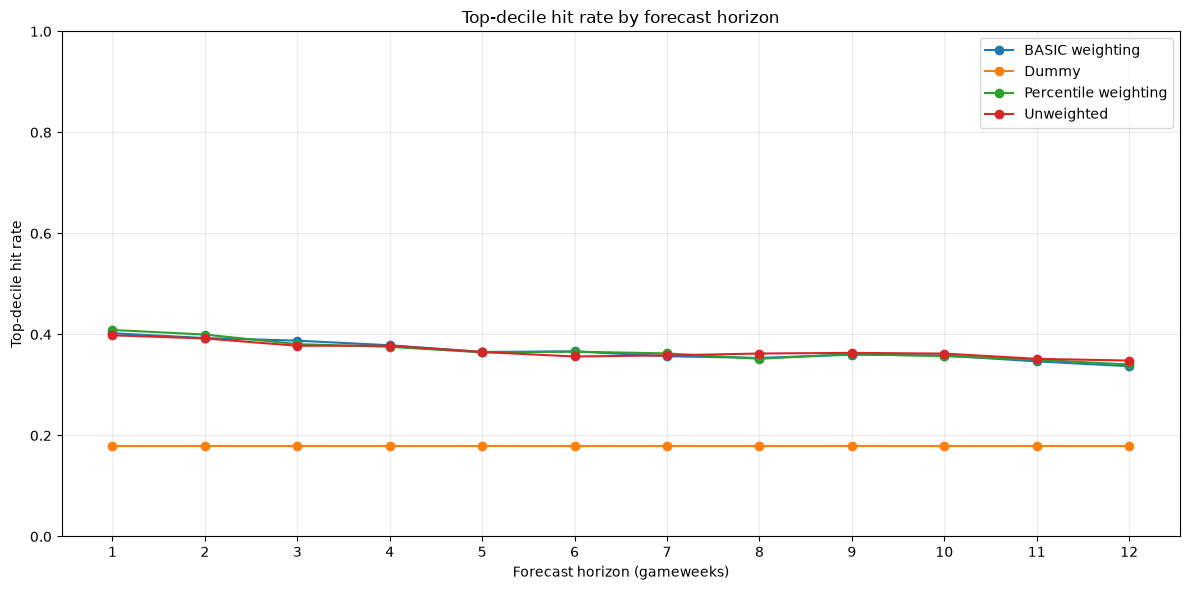

In [16]:
import gc

# Predictions are materialized, so release large objects not used below.
X_train = None
X_valid = None
fixture_history_df = None
models.clear()
dummy_model = None
basic_weighting_model = None
percentile_weighting_model = None
gc.collect()

horizon_hit_rate_records = []
validation_context = fixture_history_with_horizons_df.loc[
    y_valid.index, ["season", "target_gw", "horizon"]
].reset_index(drop=True)

for model_name, predictions in validation_predictions.items():
    evaluation = validation_context.assign(
        actual=y_valid.to_numpy(),
        predicted=predictions,
    )
    for (_, _, horizon), fixture_gameweek in evaluation.groupby(
        ["season", "target_gw", "horizon"]
    ):
        top_decile_size = max(1, int(np.ceil(len(fixture_gameweek) * 0.10)))
        predicted_top = fixture_gameweek.nlargest(top_decile_size, "predicted")
        actual_top_indices = set(
            fixture_gameweek.nlargest(top_decile_size, "actual").index
        )
        horizon_hit_rate_records.append({
            "model": model_name,
            "horizon": horizon,
            "top_decile_hit_rate": predicted_top.index.isin(
                actual_top_indices
            ).mean(),
        })

top_decile_hit_rate_by_horizon = (
    pd.DataFrame(horizon_hit_rate_records)
    .groupby(["model", "horizon"], as_index=False)["top_decile_hit_rate"]
    .mean()
    .sort_values(["model", "horizon"])
)

figure, axis = plt.subplots(figsize=(12, 6))
for model_name, model_results in top_decile_hit_rate_by_horizon.groupby("model"):
    axis.plot(
        model_results["horizon"],
        model_results["top_decile_hit_rate"],
        marker="o",
        linewidth=1.5,
        label=model_name,
    )

axis.set(
    xlabel="Forecast horizon (gameweeks)",
    ylabel="Top-decile hit rate",
    title="Top-decile hit rate by forecast horizon",
    xticks=range(1, MAX_HORIZON + 1),
    ylim=(0, 1),
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
axis

In [ ]:


save_trained_catboost_model(
    model=unweighted_model,
    feature_columns=model_features,
    categorical_columns=CATEGORICAL_COLUMNS,
    model_name="Unweighted CatBoost in-season model",
    model_version="1.0",
    save_path=IN_SEASON_ARTIFACT_PATH,
)
print(f"Saved in-season model to {IN_SEASON_ARTIFACT_PATH}")


In [17]:
model_features

['position',
 'target_gw',
 'current_gw',
 'horizon',
 'calc_total_points_mean_last_1_fixtures',
 'calc_minutes_mean_last_1_fixtures',
 'calc_goals_scored_mean_last_1_fixtures',
 'calc_assists_mean_last_1_fixtures',
 'calc_clean_sheets_mean_last_1_fixtures',
 'calc_goals_conceded_mean_last_1_fixtures',
 'calc_own_goals_mean_last_1_fixtures',
 'calc_penalties_saved_mean_last_1_fixtures',
 'calc_penalties_missed_mean_last_1_fixtures',
 'calc_yellow_cards_mean_last_1_fixtures',
 'calc_red_cards_mean_last_1_fixtures',
 'calc_saves_mean_last_1_fixtures',
 'calc_bonus_mean_last_1_fixtures',
 'calc_bps_mean_last_1_fixtures',
 'calc_influence_mean_last_1_fixtures',
 'calc_creativity_mean_last_1_fixtures',
 'calc_threat_mean_last_1_fixtures',
 'calc_ict_index_mean_last_1_fixtures',
 'calc_starts_mean_last_1_fixtures',
 'calc_expected_goals_mean_last_1_fixtures',
 'calc_expected_assists_mean_last_1_fixtures',
 'calc_expected_goal_involvements_mean_last_1_fixtures',
 'calc_expected_goals_conceded